# Checkpoint Week 2 — SVM

Vul alle cellen in en push dit bestand naar je repo. De automatische checks (GitHub Actions) voeren dit notebook uit en controleren of alle **variabelen met de gevraagde namen** bestaan en correct zijn.

**BELANGRIJK**: gebruik exact de genoemde variabelennamen (`accuracy_breast_cancer`, `y_pred_breast_cancer`, `y_pred_digits`, `accuracy_digits`, `accuracy_wine`, `y_pred_svr`, `mse_svr`, `antwoord_scaling`, `antwoord_kernel`), anders faalt de controle.

**Gebruik in elke oefening `random_state=10` en `test_size=0.25`** bij de train/test-split, anders kunnen de checks afwijken.

---
# Oefening 1 — SVM op Breast Cancer

- Laad de breast cancer dataset via `sklearn.datasets.load_breast_cancer()`.
- Splits in train/test met `test_size=0.25` en `random_state=10`.
- **Normaliseer** met een StandardScaler (fit op train alleen!).
- Train een `SVC` met `random_state=10`.
- Sla de test-voorspellingen op in `y_pred_breast_cancer` en de **accuracy op de testset** in `accuracy_breast_cancer` (float).

In [49]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# TODO: laad de dataset
X, y = load_breast_cancer(return_X_y=True)
# TODO: train/test split (test_size=0.25, random_state=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)
# TODO: StandardScaler (fit op train alleen)
scaler = StandardScaler()
scaler.fit_transform(X_train)
scaler.transform(X_test)
# TODO: train SVC(random_state=10)
svm_bc = SVC(kernel='linear', random_state=10)
svm_bc.fit(X_train, y_train)
# TODO: voorspellingen in y_pred_breast_cancer en accuracy in accuracy_breast_cancer
y_pred_breast_cancer = svm_bc.predict(X_test)
accuracy_breast_cancer = accuracy_score(y_test, y_pred_breast_cancer)
print(accuracy_breast_cancer)

0.951048951048951


**Vraag (antwoord in antwoord_scaling)**: Waarom schalen we de features vóór een SVM? Kies A, B, C of D:
- A: Omdat SVM's alleen met integers werken
- B: Omdat SVM's afstand- en inwendig-productgebaseerd zijn en schaalverschillen anders de marge domineren
- C: Omdat de accuracy dan altijd 100% wordt
- D: Omdat sklearn dat vereist voor alle modellen

In [9]:
antwoord_scaling = "B"

---
# Oefening 2 — SVM op Digits (pipeline)

- Laad de digits dataset via `sklearn.datasets.load_digits()`.
- Splits in train/test met `test_size=0.25` en `random_state=10`.
- Gebruik een **pipeline** die StandardScaler en `SVC(random_state=10)` combineert.
- Sla de test-voorspellingen op in `y_pred_digits` en de **accuracy op de testset** in `accuracy_digits` (float).

In [59]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
# TODO: laad de digits dataset
X, y = datasets.load_digits(return_X_y=True)
# TODO: train/test split (test_size=0.25, random_state=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)
# TODO: pipeline met StandardScaler + SVC(random_state=10), train en voorspel
svm_pipe = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', C=0.25, random_state=10)
)
svm_pipe.fit(X_train, y_train)
# TODO: sla op in y_pred_digits en accuracy_digits
y_pred_digits = svm_pipe.predict(X_test)
accuracy_digits = accuracy_score(y_test, y_pred_digits)
print(accuracy_digits)
# grid_search = GridSearchCV(svm_pipe, param_grid, cv=5, scoring='accuracy')
# grid_search.fit(X_train, y_train)
# print(grid_search.best_params_)
# grid_search.score(X_train, y_train)

0.9844444444444445


**Vraag (antwoord in antwoord_kernel)**: Voor de digits-dataset, welke kernel presteert doorgaans het best? Kies A, B, C of D:
- A: linear
- B: poly
- C: rbf
- D: sigmoid

In [54]:
antwoord_kernel = "A"

---
# Oefening 3 — SVM op Wine (meerklass)

- Laad de wine dataset via `sklearn.datasets.load_wine()`.
- Splits in train/test met `test_size=0.25` en `random_state=10`.
- Train een `SVC(random_state=10)` **in een pipeline met StandardScaler**.
- Sla de **accuracy op de testset** op in `accuracy_wine` (float).

In [25]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# TODO: laad de wine dataset
X, y = load_wine(return_X_y=True)
# TODO: train/test split (test_size=0.25, random_state=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)
# TODO: pipeline met StandardScaler + SVC(random_state=10)
svm_wine = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=0.25, random_state=10)
)
svm_wine.fit(X_train,y_train)
# TODO: sla de test-accuracy op in accuracy_wine
y_pred_wine = svm_wine.predict(X_test)
accuracy_wine = accuracy_score(y_test, y_pred_wine)
print(accuracy_wine)

0.9555555555555556


---
# Oefening 4 — SVR (regressie)

- Genereer de kwadratische dataset (staat al in de cel hieronder).
- Train een SVR met kernel `poly`, `degree=2`, `C=0.01`, `epsilon=0.1` in een pipeline met StandardScaler.
- Sla de voorspellingen op de trainingsdata op in `y_pred_svr` en de **MSE op de trainingsdata** in `mse_svr` (float).

In [ ]:
import numpy as np
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

np.random.seed(42)
X = 2 * np.random.rand(50, 1) - 1
y = 0.2 + 0.1 * X[:, 0] + 0.5 * X[:, 0] ** 2 + np.random.randn(50) / 10

# TODO: pipeline met StandardScaler + SVR(kernel='poly', degree=2, C=0.01, epsilon=0.1)
svr_pipe = make_pipeline(
    StandardScaler(),
    SVR(kernel='poly', degree=2, C=0.01, epsilon=0.1)
)
svr_pipe.fit(X, y)
# TODO: voorspel op X -> y_pred_svr, bereken MSE -> mse_svr
y_pred_svr = svr_pipe.predict(X)
mse_svr = mean_squared_error(y, y_pred_svr)
print(mse_svr)

0.010407700266361196


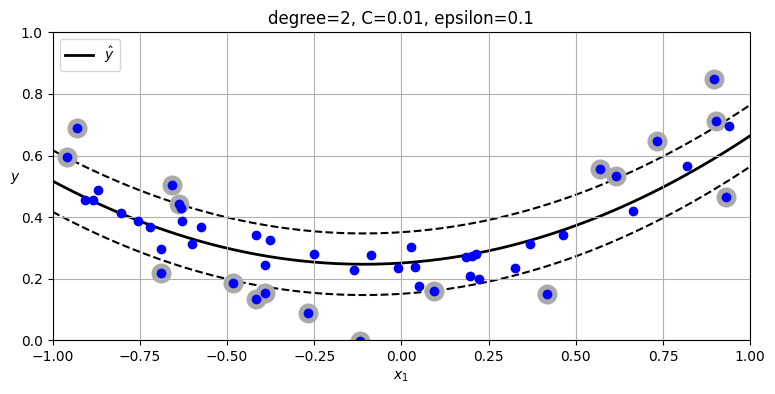

In [52]:

import matplotlib.pyplot as plt

def find_support_vectors(svm_reg, X, y):
    y_pred = svm_reg.predict(X)
    epsilon = svm_reg[-1].epsilon
    off_margin = np.abs(y - y_pred) >= epsilon
    return np.argwhere(off_margin)

def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)
    y_pred = svm_reg.predict(x1s)
    epsilon = svm_reg[-1].epsilon
    plt.plot(x1s, y_pred, "k-", linewidth=2, label=r"$\hat{y}$", zorder=-2)
    plt.plot(x1s, y_pred + epsilon, "k--", zorder=-2)
    plt.plot(x1s, y_pred - epsilon, "k--", zorder=-2)
    plt.scatter(X[svm_reg._support], y[svm_reg._support], s=180,
                facecolors='#AAA', zorder=-1)
    plt.plot(X, y, "bo")
    plt.xlabel("$x_1$")
    plt.legend(loc="upper left")
    plt.axis(axes)

svr_pipe._support = find_support_vectors(svr_pipe, X, y)

fig, axes = plt.subplots(ncols=1, figsize=(9, 4), sharey=True)
plt.sca(axes)
plot_svm_regression(svr_pipe, X, y, [-1, 1, 0, 1])
plt.title(f"degree={svr_pipe[-1].degree}, "
          f"C={svr_pipe[-1].C}, "
          f"epsilon={svr_pipe[-1].epsilon}")
plt.ylabel("$y$", rotation=0)
plt.grid()

plt.show()